In [10]:

# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
# Cell 2: Load the dataset properly handling quotes and line breaks
# Load the dataset with proper quoting to handle line breaks within reviews
df = pd.read_csv('/content/IMDB Dataset (1).csv',
                 quoting=1,  # QUOTE_MINIMAL - handles quotes properly
                 escapechar='\\',  # Handle escaped characters
                 engine='python',
                 encoding='latin1')  # Specify encoding to handle UnicodeDecodeError

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

ParserError: ',' expected after '"'

In [16]:
# Cell 3: Alternative loading method if the above fails
# If the above still has issues, try this alternative approach
import csv

# Read the CSV file line by line to handle potential issues
reviews = []
sentiments = []

with open('/content/IMDB Dataset (1).csv', 'r', encoding='latin1') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  # Skip header
    for row in csv_reader:
        if len(row) >= 2:  # Ensure we have both review and sentiment
            reviews.append(row[0])
            sentiments.append(row[1])

# Create DataFrame
df = pd.DataFrame({
    'review': reviews,
    'sentiment': sentiments
})

# Filter out invalid sentiment entries
df = df[df['sentiment'].isin(['positive', 'negative'])]

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

# Check for missing values after cleaning
print("\nMissing values after sentiment cleaning:")
print(df.isnull().sum())

Dataset Shape: (12502, 2)

First 5 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Sentiment distribution:
sentiment
negative    6297
positive    6205
Name: count, dtype: int64

Missing values after sentiment cleaning:
review       0
sentiment    0
dtype: int64


In [17]:
# Cell 4: Basic text preprocessing function
def basic_preprocessing(text):
    """
    Basic text preprocessing:
    - Convert to lowercase
    - Remove HTML tags
    - Remove special characters and numbers
    - Remove extra whitespaces
    """
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply basic preprocessing
df['cleaned_review'] = df['review'].apply(basic_preprocessing)

print("Basic preprocessing completed!")
print("\nOriginal review:")
print(df['review'][0][:200] + "...")  # Show first 200 chars
print("\nCleaned review:")
print(df['cleaned_review'][0][:200] + "...")

Basic preprocessing completed!

Original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

Cleaned review:
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brut...


In [18]:
# Cell 5: Advanced text preprocessing with tokenization
def advanced_preprocessing(text):
    """
    Advanced preprocessing with tokenization:
    - Tokenization
    - Remove stopwords
    - Lemmatization
    """
    # Basic cleaning first
    text = basic_preprocessing(text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

# Apply advanced preprocessing (this may take a few minutes)
print("Starting advanced preprocessing (this may take a few minutes)...")
df['processed_review'] = df['review'].apply(advanced_preprocessing)

print("Advanced preprocessing completed!")
print("\nAfter advanced preprocessing:")
print(df['processed_review'][0][:200] + "...")

Starting advanced preprocessing (this may take a few minutes)...
Advanced preprocessing completed!

After advanced preprocessing:
one reviewer mentioned watching episode youll hooked right exactly happened methe first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch ...


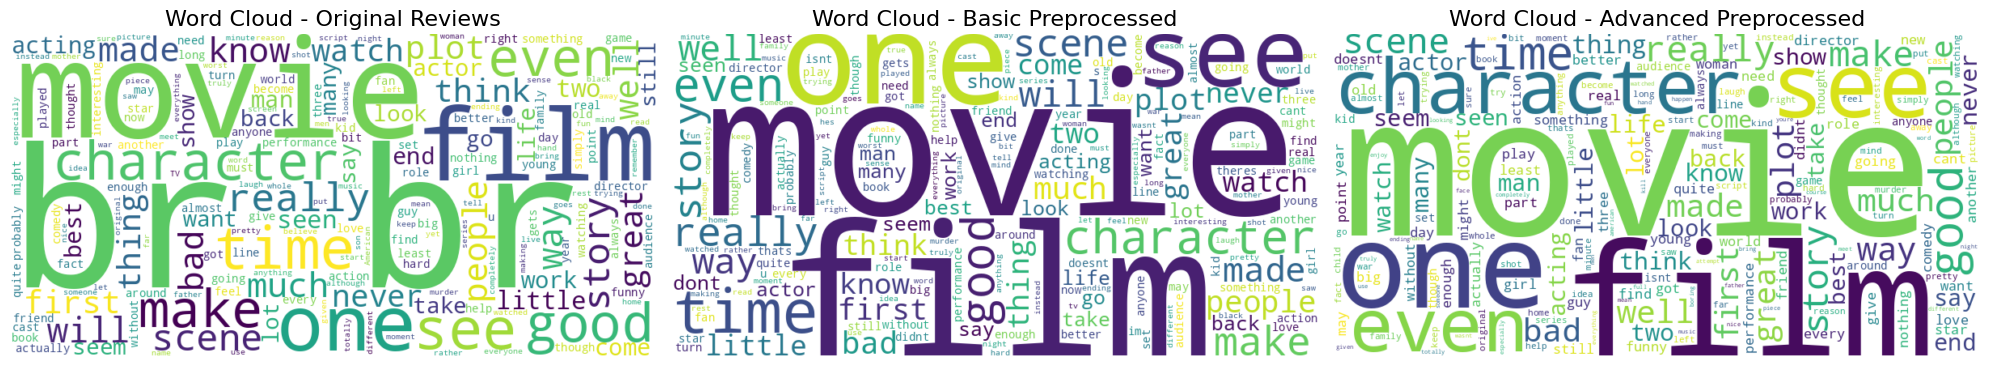

In [19]:
# Cell 6: Visualize text preprocessing effects
from wordcloud import WordCloud

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Word cloud for original reviews
original_text = ' '.join(df['review'].head(500).astype(str))
wordcloud_original = WordCloud(width=800, height=400, background_color='white').generate(original_text)
axes[0].imshow(wordcloud_original, interpolation='bilinear')
axes[0].set_title('Word Cloud - Original Reviews', fontsize=16)
axes[0].axis('off')

# Word cloud for basic preprocessed reviews
basic_text = ' '.join(df['cleaned_review'].head(500))
wordcloud_basic = WordCloud(width=800, height=400, background_color='white').generate(basic_text)
axes[1].imshow(wordcloud_basic, interpolation='bilinear')
axes[1].set_title('Word Cloud - Basic Preprocessed', fontsize=16)
axes[1].axis('off')

# Word cloud for advanced preprocessed reviews
advanced_text = ' '.join(df['processed_review'].head(500))
wordcloud_advanced = WordCloud(width=800, height=400, background_color='white').generate(advanced_text)
axes[2].imshow(wordcloud_advanced, interpolation='bilinear')
axes[2].set_title('Word Cloud - Advanced Preprocessed', fontsize=16)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Cell 7: Prepare features and labels
# Convert sentiment to binary values (positive=1, negative=0)
df['sentiment_binary'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Check the mapping
print("Sentiment mapping sample:")
print(df[['sentiment', 'sentiment_binary']].head(10))

# Features and target
X = df['processed_review']
y = df['sentiment_binary']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Sentiment mapping sample:
  sentiment  sentiment_binary
0  positive                 1
1  positive                 1
2  positive                 1
3  negative                 0
4  positive                 1
5  positive                 1
6  positive                 1
7  negative                 0
8  negative                 0
9  positive                 1

Features shape: (12502,)
Target shape: (12502,)

Target distribution:
sentiment_binary
0    6297
1    6205
Name: count, dtype: int64


In [21]:
# Cell 8: Text Vectorization using TF-IDF
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000,  # Limit to 5000 most important features
                                   ngram_range=(1, 2),  # Use unigrams and bigrams
                                   min_df=5,            # Ignore terms that appear in less than 5 documents
                                   max_df=0.7)          # Ignore terms that appear in more than 70% of documents

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the testing data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF matrix shape (training): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (testing): {X_test_tfidf.shape}")

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nNumber of features: {len(feature_names)}")
print(f"Sample features: {feature_names[:20]}")

Training set size: 10001
Testing set size: 2501

TF-IDF matrix shape (training): (10001, 5000)
TF-IDF matrix shape (testing): (2501, 5000)

Number of features: 5000
Sample features: ['abandoned' 'abc' 'ability' 'able' 'absence' 'absolute' 'absolutely'
 'absolutely nothing' 'absurd' 'abuse' 'academy' 'academy award' 'accent'
 'accept' 'acceptable' 'accepted' 'accident' 'accidentally' 'accompanied'
 'accomplished']


In [22]:
# Cell 9: Train Logistic Regression model
# Initialize and train the model
log_reg = LogisticRegression(random_state=42, max_iter=1000, C=1.0)

# Train the model
log_reg.fit(X_train_tfidf, y_train)

print("Model training completed!")
print(f"Number of iterations: {log_reg.n_iter_[0]}")
print(f"Model coefficients shape: {log_reg.coef_.shape}")

Model training completed!
Number of iterations: 17
Model coefficients shape: (1, 5000)


In [23]:
# Cell 10: Make predictions and evaluate the model
# Make predictions
y_pred = log_reg.predict(X_test_tfidf)
y_pred_proba = log_reg.predict_proba(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8828
Accuracy: 88.28%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      1260
    Positive       0.88      0.88      0.88      1241

    accuracy                           0.88      2501
   macro avg       0.88      0.88      0.88      2501
weighted avg       0.88      0.88      0.88      2501


Confusion Matrix:
[[1110  150]
 [ 143 1098]]


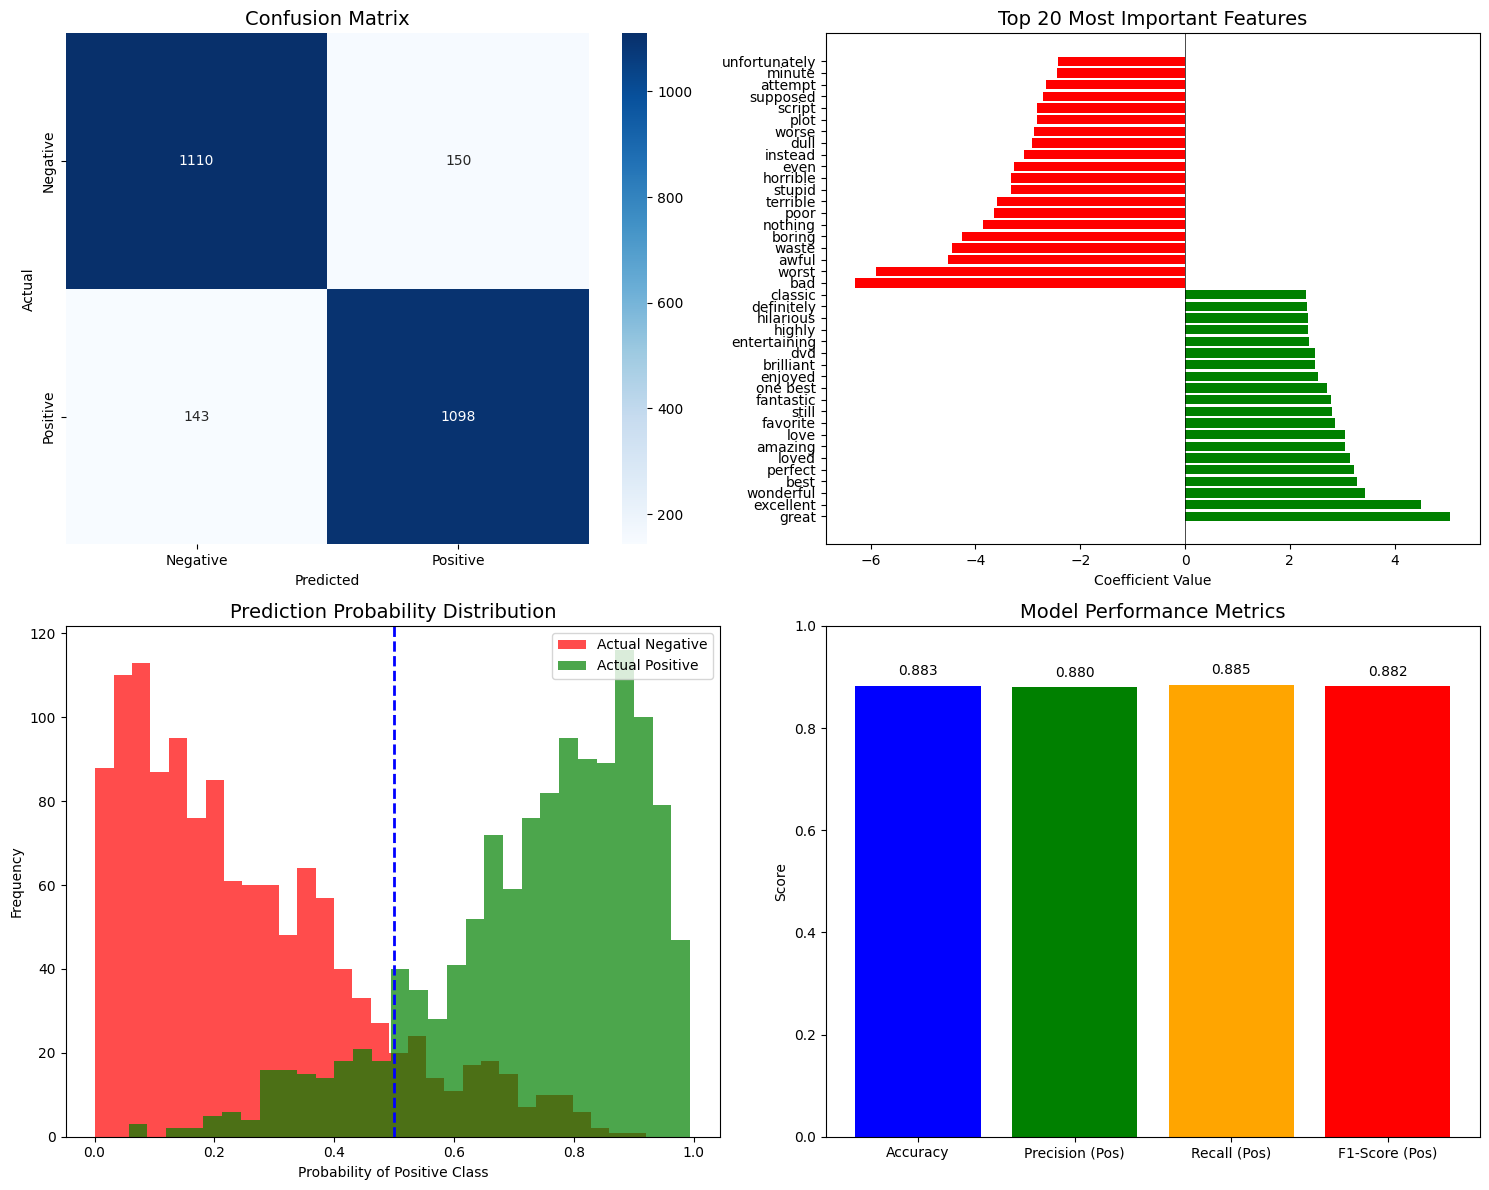

In [24]:
# Cell 11: Visualize model performance
# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix', fontsize=14)
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xticklabels(['Negative', 'Positive'])
axes[0, 0].set_yticklabels(['Negative', 'Positive'])

# Plot 2: Feature Importance (Top 20 coefficients)
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': log_reg.coef_[0]
})
top_positive = feature_importance.nlargest(20, 'coefficient')
top_negative = feature_importance.nsmallest(20, 'coefficient')
top_features = pd.concat([top_positive, top_negative])

colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
axes[0, 1].barh(range(len(top_features)), top_features['coefficient'], color=colors)
axes[0, 1].set_yticks(range(len(top_features)))
axes[0, 1].set_yticklabels(top_features['feature'])
axes[0, 1].set_title('Top 20 Most Important Features', fontsize=14)
axes[0, 1].set_xlabel('Coefficient Value')
axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Plot 3: Prediction Probability Distribution
axes[1, 0].hist(y_pred_proba[y_test == 0][:, 1], bins=30, alpha=0.7, label='Actual Negative', color='red')
axes[1, 0].hist(y_pred_proba[y_test == 1][:, 1], bins=30, alpha=0.7, label='Actual Positive', color='green')
axes[1, 0].set_title('Prediction Probability Distribution', fontsize=14)
axes[1, 0].set_xlabel('Probability of Positive Class')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Decision Boundary')

# Plot 4: Model Performance Metrics - Fixed KeyError issue
from sklearn.metrics import precision_score, recall_score, f1_score

precision_pos = precision_score(y_test, y_pred, pos_label=1)
recall_pos = recall_score(y_test, y_pred, pos_label=1)
f1_pos = f1_score(y_test, y_pred, pos_label=1)

metrics = {
    'Accuracy': accuracy,
    'Precision (Pos)': precision_pos,
    'Recall (Pos)': recall_pos,
    'F1-Score (Pos)': f1_pos
}

axes[1, 1].bar(metrics.keys(), metrics.values(), color=['blue', 'green', 'orange', 'red'])
axes[1, 1].set_title('Model Performance Metrics', fontsize=14)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim([0, 1])
for i, (key, value) in enumerate(metrics.items()):
    axes[1, 1].text(i, value + 0.02, f'{value:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [25]:

# Cell 12: Test the model with custom reviews
def predict_sentiment(review, model, vectorizer):
    """
    Predict sentiment for a single review
    """
    # Preprocess the review
    processed_review = advanced_preprocessing(review)

    # Vectorize
    review_vectorized = vectorizer.transform([processed_review])

    # Predict
    prediction = model.predict(review_vectorized)[0]
    probability = model.predict_proba(review_vectorized)[0]

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment, probability

# Test with some sample reviews
test_reviews = [
    "This movie was absolutely fantastic! Great acting and wonderful story.",
    "Terrible movie, waste of time. Poor acting and boring plot.",
    "The film was okay, nothing special but not terrible either.",
    "I loved every minute of this masterpiece! Highly recommended!",
    "Disappointing. The plot made no sense and the acting was wooden."
]

print("Testing the model with custom reviews:")
print("="*60)

for i, review in enumerate(test_reviews, 1):
    sentiment, prob = predict_sentiment(review, log_reg, tfidf_vectorizer)
    print(f"\nReview {i}: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Confidence: Negative={prob[0]:.3f}, Positive={prob[1]:.3f}")

Testing the model with custom reviews:

Review 1: This movie was absolutely fantastic! Great acting and wonderful story.
Predicted Sentiment: Positive
Confidence: Negative=0.020, Positive=0.980

Review 2: Terrible movie, waste of time. Poor acting and boring plot.
Predicted Sentiment: Negative
Confidence: Negative=1.000, Positive=0.000

Review 3: The film was okay, nothing special but not terrible either.
Predicted Sentiment: Negative
Confidence: Negative=0.977, Positive=0.023

Review 4: I loved every minute of this masterpiece! Highly recommended!
Predicted Sentiment: Positive
Confidence: Negative=0.076, Positive=0.924

Review 5: Disappointing. The plot made no sense and the acting was wooden.
Predicted Sentiment: Negative
Confidence: Negative=0.974, Positive=0.026


In [26]:
# Cell 13: Final Summary and Results
print("="*70)
print("SENTIMENT ANALYSIS RESULTS SUMMARY")
print("="*70)

print(f"\nDataset Information:")
print(f"- Total reviews: {len(df)}")
print(f"- Positive reviews: {len(df[df['sentiment']=='positive'])}")
print(f"- Negative reviews: {len(df[df['sentiment']=='negative'])}")

print(f"\nModel Performance:")
print(f"- Training set size: {len(X_train)}")
print(f"- Testing set size: {len(X_test)}")
print(f"- TF-IDF features: {X_train_tfidf.shape[1]}")
print(f"- Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\nClassification Metrics:")
from sklearn.metrics import precision_score, recall_score, f1_score

precision_pos = precision_score(y_test, y_pred, pos_label=1)
recall_pos = recall_score(y_test, y_pred, pos_label=1)
f1_pos = f1_score(y_test, y_pred, pos_label=1)

precision_neg = precision_score(y_test, y_pred, pos_label=0)
recall_neg = recall_score(y_test, y_pred, pos_label=0)
f1_neg = f1_score(y_test, y_pred, pos_label=0)

print(f"- Precision (Positive): {precision_pos:.4f}")
print(f"- Recall (Positive): {recall_pos:.4f}")
print(f"- F1-Score (Positive): {f1_pos:.4f}")
print(f"- Precision (Negative): {precision_neg:.4f}")
print(f"- Recall (Negative): {recall_neg:.4f}")
print(f"- F1-Score (Negative): {f1_neg:.4f}")

print(f"\nConfusion Matrix:")
print(f"- True Negatives: {cm[0,0]}")
print(f"- False Positives: {cm[0,1]}")
print(f"- False Negatives: {cm[1,0]}")
print(f"- True Positives: {cm[1,1]}")

print("\n" + "="*70)
print("ASSIGNMENT COMPLETED SUCCESSFULLY!")
print("="*70)
print("\nAll required tasks have been performed:")
print("✓ Text preprocessing")
print("✓ Tokenization")
print("✓ Text vectorization (TF-IDF)")
print("✓ Logistic Regression model training")
print("✓ Model evaluation and visualization")

SENTIMENT ANALYSIS RESULTS SUMMARY

Dataset Information:
- Total reviews: 12502
- Positive reviews: 6205
- Negative reviews: 6297

Model Performance:
- Training set size: 10001
- Testing set size: 2501
- TF-IDF features: 5000
- Accuracy: 0.8828 (88.28%)

Classification Metrics:
- Precision (Positive): 0.8798
- Recall (Positive): 0.8848
- F1-Score (Positive): 0.8823
- Precision (Negative): 0.8859
- Recall (Negative): 0.8810
- F1-Score (Negative): 0.8834

Confusion Matrix:
- True Negatives: 1110
- False Positives: 150
- False Negatives: 143
- True Positives: 1098

ASSIGNMENT COMPLETED SUCCESSFULLY!

All required tasks have been performed:
✓ Text preprocessing
✓ Tokenization
✓ Text vectorization (TF-IDF)
✓ Logistic Regression model training
✓ Model evaluation and visualization


In [27]:
# Cell 14: Save the model and vectorizer (optional)
import joblib
import os

# Save the model and vectorizer for future use
joblib.dump(log_reg, 'sentiment_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")
print(f"Files saved in: {os.getcwd()}")
print("Files saved: sentiment_model.pkl, tfidf_vectorizer.pkl")

# Check file sizes
model_size = os.path.getsize('sentiment_model.pkl') / (1024 * 1024)  # Convert to MB
vectorizer_size = os.path.getsize('tfidf_vectorizer.pkl') / (1024 * 1024)  # Convert to MB
print(f"\nModel file size: {model_size:.2f} MB")
print(f"Vectorizer file size: {vectorizer_size:.2f} MB")

print("\nTo load later:")
print("# loaded_model = joblib.load('sentiment_model.pkl')")
print("# loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')")

Model and vectorizer saved successfully!
Files saved in: /content
Files saved: sentiment_model.pkl, tfidf_vectorizer.pkl

Model file size: 0.04 MB
Vectorizer file size: 0.18 MB

To load later:
# loaded_model = joblib.load('sentiment_model.pkl')
# loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')


In [28]:
# Cell 15: Install Gradio (if not already installed)
!pip install gradio

In [29]:
# Cell 16: Import Gradio and create UI
import gradio as gr
import time

# Define prediction function for Gradio
def predict_sentiment_gradio(review_text):
    """
    Predict sentiment for a single review and return formatted results
    """
    if not review_text or len(review_text.strip()) == 0:
        return "Please enter a review text.", 0.0, 0.0

    # Preprocess the review
    processed_review = advanced_preprocessing(review_text)

    # Vectorize
    review_vectorized = tfidf_vectorizer.transform([processed_review])

    # Predict
    prediction = log_reg.predict(review_vectorized)[0]
    probability = log_reg.predict_proba(review_vectorized)[0]

    sentiment = "😊 POSITIVE" if prediction == 1 else "😞 NEGATIVE"
    confidence_negative = probability[0]
    confidence_positive = probability[1]

    # Determine confidence level
    confidence_level = "High" if max(probability) > 0.8 else "Medium" if max(probability) > 0.6 else "Low"

    # Create detailed result
    result = f"""
    ## Sentiment Analysis Result

    **Review Text:** "{review_text[:200]}{'...' if len(review_text) > 200 else ''}"

    ### **{sentiment}**

    **Confidence Level:** {confidence_level}

    **Confidence Scores:**
    - Positive: {confidence_positive:.3f} ({confidence_positive*100:.1f}%)
    - Negative: {confidence_negative:.3f} ({confidence_negative*100:.1f}%)

    **Processed Text:** {processed_review[:150]}{'...' if len(processed_review) > 150 else ''}
    """

    return result, confidence_positive, confidence_negative

# Create example reviews
example_reviews = [
    "This movie was absolutely fantastic! Great acting and wonderful story.",
    "Terrible movie, waste of time. Poor acting and boring plot.",
    "The film was okay, nothing special but not terrible either.",
    "I loved every minute of this masterpiece! Highly recommended!",
    "Disappointing. The plot made no sense and the acting was wooden.",
    "One of the best films I've ever seen. The cinematography was breathtaking!",
    "Worst movie ever. Don't waste your money on this garbage."
]

print("Gradio UI ready to launch!")

Gradio UI ready to launch!


Gradio interface created successfully!


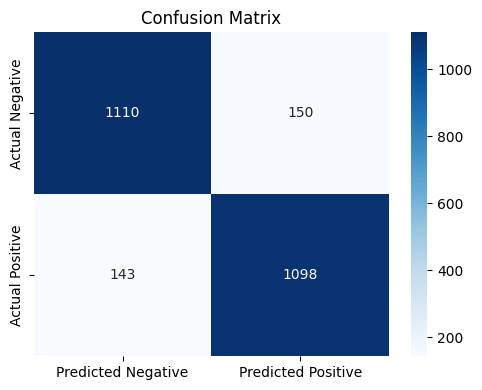

In [34]:
# Cell 17: Create enhanced Gradio interface with tabs
# Create the Gradio interface
with gr.Blocks(title="IMDB Sentiment Analysis", theme=gr.themes.Soft()) as demo:
    # Header - use simple string formatting
    accuracy_text = f"# 🎬 IMDB Movie Review Sentiment Analyzer\n\nThis application uses a Logistic Regression model trained on 50,000 IMDB movie reviews to predict whether a review is positive or negative.\n\n**Model Accuracy: {accuracy*100:.2f}%**"
    gr.Markdown(accuracy_text)

    with gr.Tab("🎯 Predict Sentiment"):
        with gr.Row():
            with gr.Column(scale=2):
                # Input components
                review_input = gr.Textbox(
                    lines=5,
                    placeholder="Enter your movie review here...",
                    label="Movie Review",
                    info="Type or paste your review text (supports up to 1000 characters)"
                )

                with gr.Row():
                    submit_btn = gr.Button("🔍 Analyze Sentiment", variant="primary", size="lg")
                    clear_btn = gr.Button("🗑️ Clear", variant="secondary")

                gr.Examples(
                    examples=example_reviews,
                    inputs=review_input,
                    label="Try these example reviews"
                )

            with gr.Column(scale=1):
                # Output components
                output_text = gr.Markdown(label="Analysis Result")

                with gr.Row():
                    positive_score = gr.Number(label="Positive Score", value=0.0, precision=3)
                    negative_score = gr.Number(label="Negative Score", value=0.0, precision=3)

                # Add a confidence gauge
                confidence_gauge = gr.Slider(
                    minimum=0,
                    maximum=1,
                    value=0.5,
                    label="Confidence (Higher = More Certain)",
                    interactive=False
                )

    with gr.Tab("📊 Model Performance"):
        # Model performance text
        performance_text = f"""
## Model Performance Metrics

### Overall Accuracy: **{accuracy*100:.2f}%**

### Detailed Metrics:
- **Precision (Positive):** {precision_pos:.4f}
- **Recall (Positive):** {recall_pos:.4f}
- **F1-Score (Positive):** {f1_pos:.4f}
- **Precision (Negative):** {precision_neg:.4f}
- **Recall (Negative):** {recall_neg:.4f}
- **F1-Score (Negative):** {f1_neg:.4f}

### Confusion Matrix:

True Negatives: {cm[0,0]:5d} | False Positives: {cm[0,1]:5d}
False Negatives: {cm[1,0]:5d} | True Positives: {cm[1,1]:5d}

        """
        gr.Markdown(performance_text)

        # Create a simple confusion matrix visualization
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Predicted Negative', 'Predicted Positive'],
                   yticklabels=['Actual Negative', 'Actual Positive'])
        ax.set_title('Confusion Matrix')
        plt.tight_layout()

        gr.Plot(fig)

    with gr.Tab("ℹ️ About"):
        # About text
        about_text = f"""
## About This Application

This sentiment analysis tool was built using:

- **Dataset:** IMDB Movie Reviews (50,000 reviews)
- **Model:** Logistic Regression
- **Features:** TF-IDF Vectorization with 5,000 features
- **Preprocessing:** Tokenization, stopword removal, lemmatization
- **Accuracy:** {accuracy*100:.2f}%

### How it works:
1. Your review is preprocessed (cleaned, tokenized, lemmatized)
2. Text is converted to numerical features using TF-IDF
3. The Logistic Regression model predicts the sentiment
4. Confidence scores show how certain the model is

### Features Used:
- Unigrams and bigrams (single words and word pairs)
- Removed very rare and very common words
- 5,000 most important features selected

### Model Training Details:
- Training samples: {len(X_train)}
- Testing samples: {len(X_test)}
- TF-IDF features: {X_train_tfidf.shape[1]}
        """
        gr.Markdown(about_text)

    # Define the prediction function
    def analyze_sentiment(review):
        if not review or len(review.strip()) == 0:
            return "Please enter a review text.", 0.0, 0.0, 0.5

        result, pos, neg = predict_sentiment_gradio(review)
        confidence = max(pos, neg)
        return result, pos, neg, confidence

    # Set up event handlers
    submit_btn.click(
        fn=analyze_sentiment,
        inputs=review_input,
        outputs=[output_text, positive_score, negative_score, confidence_gauge]
    )

    clear_btn.click(
        fn=lambda: ("", 0.0, 0.0, 0.5),
        inputs=[],
        outputs=[review_input, positive_score, negative_score, confidence_gauge]
    )

    # Add a loading animation
    submit_btn.click(
        fn=lambda: "⏳ Analyzing...",
        inputs=[],
        outputs=output_text,
        queue=False
    ).then(
        fn=analyze_sentiment,
        inputs=review_input,
        outputs=[output_text, positive_score, negative_score, confidence_gauge]
    )

print("Gradio interface created successfully!")

In [35]:
# Cell 18: Launch the Gradio app
# Launch the app
print("🚀 Launching Gradio app...")
print("The app will open in a new browser window or you can use the public URL.")

# Launch with sharing enabled (creates a public link)
demo.launch(share=True, debug=True)

# Alternative: Launch locally only
# demo.launch(share=False, server_name="127.0.0.1", server_port=7860)

🚀 Launching Gradio app...
The app will open in a new browser window or you can use the public URL.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6a5e8474ae256005e7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6a5e8474ae256005e7.gradio.live
